# Day 3 - Univariate & Bivariate EDA

## Objective

Perform Exploratory Data Analysis (EDA) on the cleaned AI Job Market dataset.

### Tasks

- Univariate Analysis
- Categorical Univariate Analysis
- Numeric-Numeric Analysis
- Numeric-Categorical Analysis
- Segment Analysis
- Export Visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("../data/interim/cleaned_day2.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (50000, 14)


,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large


In [4]:
import os

os.makedirs("../reports/figures", exist_ok=True)

print("Figures folder ready")

Figures folder ready


# Univariate Analysis

## Salary Distribution

The salary_min_usd column is analyzed using:

- Histogram
- KDE (Kernel Density Estimation)
- Boxplot

This helps understand the distribution and spread of salaries.

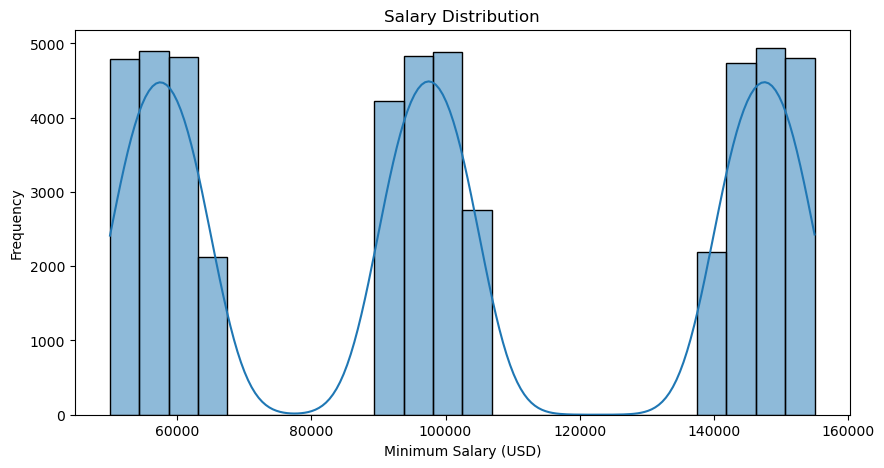

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['salary_min_usd'],
    kde=True
)

plt.title("Salary Distribution")
plt.xlabel("Minimum Salary (USD)")
plt.ylabel("Frequency")

plt.show()

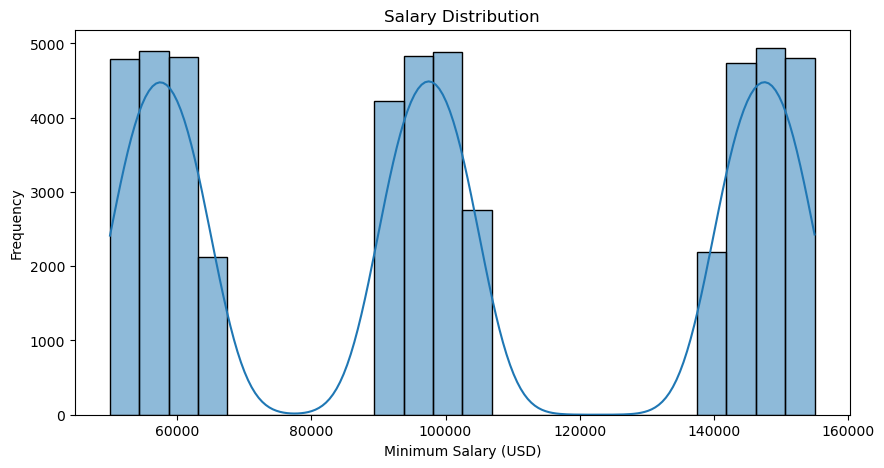

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['salary_min_usd'],
    kde=True
)

plt.title("Salary Distribution")
plt.xlabel("Minimum Salary (USD)")
plt.ylabel("Frequency")

plt.savefig(
    "../reports/figures/salary_distribution.png",
    bbox_inches="tight"
)

plt.show()

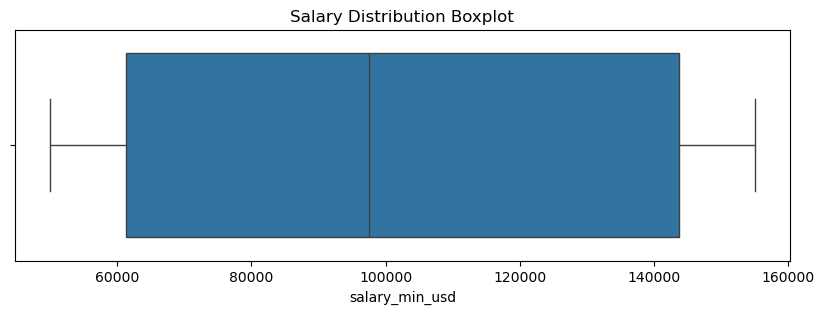

In [7]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df['salary_min_usd']
)

plt.title("Salary Distribution Boxplot")

plt.show()

In [8]:
df['salary_min_usd'].describe()

count     50000.000000
mean     100871.434320
std       37043.446641
min       50000.000000
25%       61287.000000
50%       97505.000000
75%      143730.500000
max      154999.000000
Name: salary_min_usd, dtype: float64

## Salary Distribution Findings

- Salary distribution was visualized using histogram and KDE.
- Boxplot was used to inspect potential outliers.
- Descriptive statistics were reviewed.
- Most salaries are concentrated around the middle salary range.
- No significant outlier issues were observed during Day 2 preprocessing.

# Categorical Univariate Analysis

## Job Title Distribution

The frequency of different job titles is analyzed using:

- Frequency table
- Bar chart

This helps identify the most common AI-related roles in the dataset.

In [9]:
job_counts = df['job_title'].value_counts()

job_counts

job_title
MLOps Engineer               8439
AI Researcher                8415
Data Scientist               8410
Applied Scientist            8298
Data Analyst                 8260
Machine Learning Engineer    8178
Name: count, dtype: int64

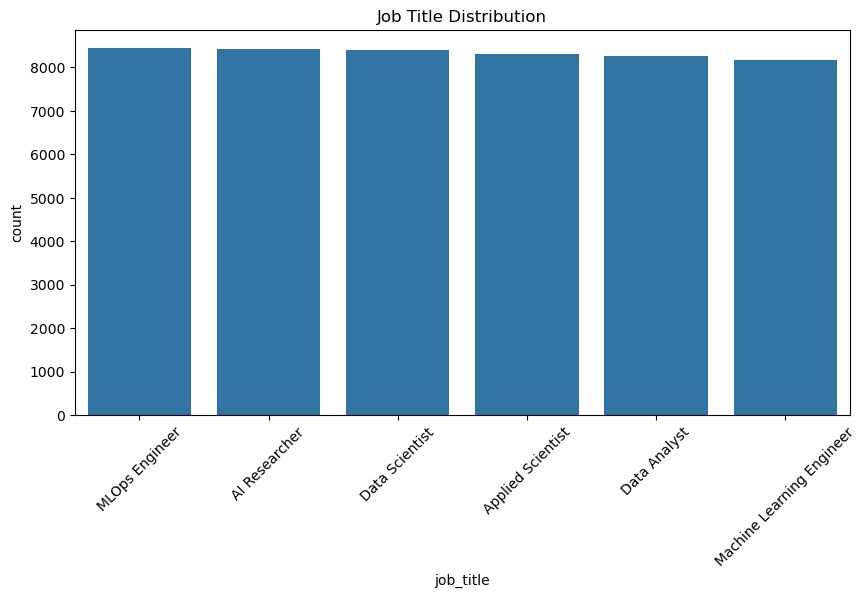

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='job_title',
    order=df['job_title'].value_counts().index
)

plt.title("Job Title Distribution")
plt.xticks(rotation=45)

plt.show()

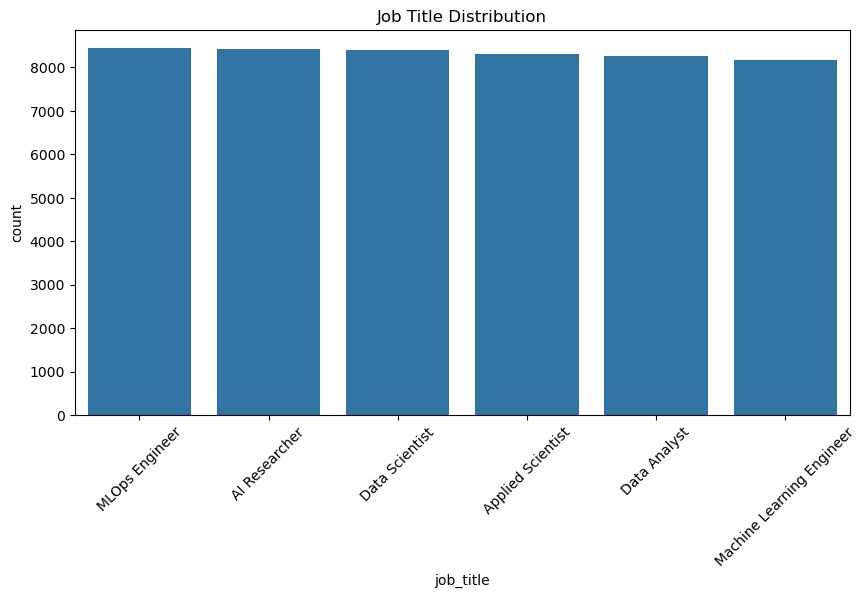

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='job_title',
    order=df['job_title'].value_counts().index
)

plt.title("Job Title Distribution")
plt.xticks(rotation=45)

plt.savefig(
    "../reports/figures/job_title_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Job Title Findings

- Job title frequencies were analyzed using a frequency table and bar chart.
- The chart highlights the most common AI and Data Science roles.
- This helps understand demand patterns within the job market dataset.

# Country Distribution Analysis

The distribution of job postings across countries is analyzed using:

- Frequency table
- Bar chart

This helps identify which countries contribute the most AI and Data Science jobs.

In [12]:
country_counts = df['country'].value_counts()

country_counts

country
UK           8452
India        8350
Germany      8345
Canada       8303
Australia    8276
USA          8274
Name: count, dtype: int64

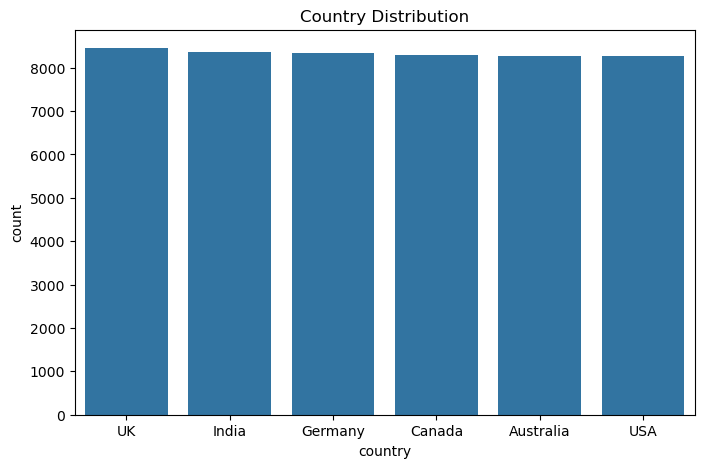

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='country',
    order=df['country'].value_counts().index
)

plt.title("Country Distribution")

plt.show()

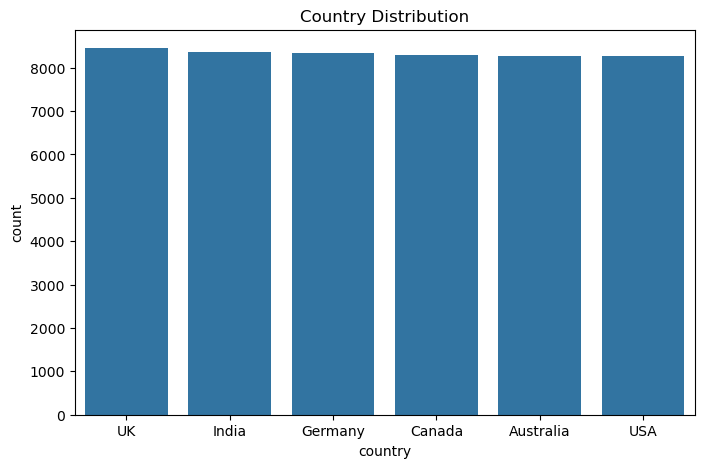

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='country',
    order=df['country'].value_counts().index
)

plt.title("Country Distribution")

plt.savefig(
    "../reports/figures/country_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Country Distribution Findings

- Job postings were analyzed across countries.
- The bar chart highlights the countries with the highest representation.
- This analysis helps understand geographic distribution of AI and Data Science opportunities.

# Correlation Analysis

Correlation analysis is performed on numerical variables to identify relationships between features.

A correlation heatmap is used to visualize these relationships.

In [15]:
numerical_cols = [
    'min_experience_years',
    'salary_min_usd',
    'salary_max_usd',
    'posted_year'
]

correlation_matrix = df[numerical_cols].corr()

correlation_matrix

,min_experience_years,salary_min_usd,salary_max_usd,posted_year
min_experience_years,1.000000,0.991867,0.980046,-0.004057
salary_min_usd,0.991867,1.000000,0.974541,-0.003718
salary_max_usd,0.980046,0.974541,1.000000,-0.005150
posted_year,-0.004057,-0.003718,-0.005150,1.000000


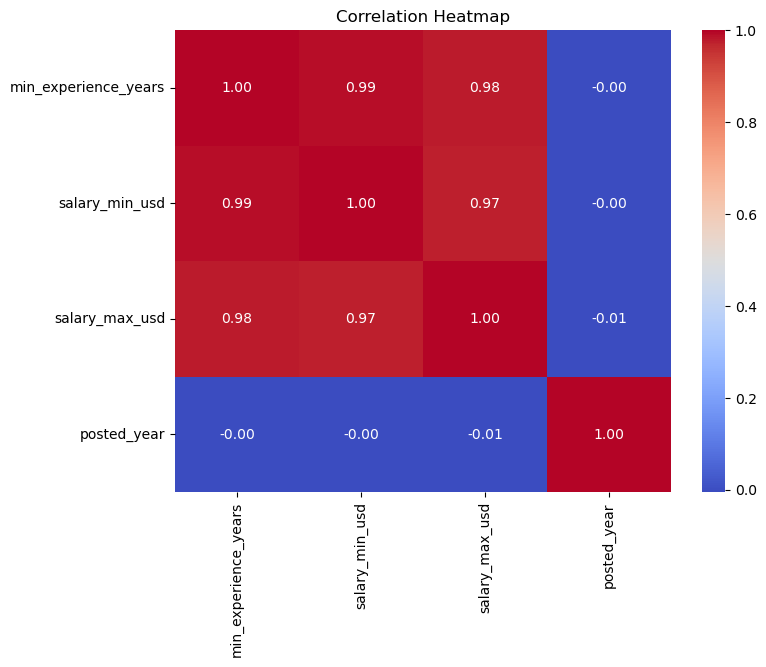

In [16]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

# Salary vs Experience Level

A boxplot is used to compare salary distributions across different experience levels.

This helps identify how salary changes with experience.

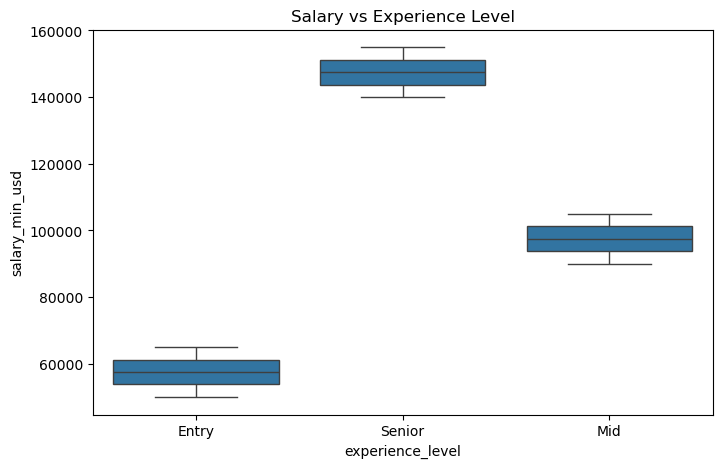

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='experience_level',
    y='salary_min_usd'
)

plt.title("Salary vs Experience Level")

plt.savefig(
    "../reports/figures/salary_vs_experience.png",
    bbox_inches="tight"
)

plt.show()

# Salary vs Company Size

Salary distributions are compared across company sizes.

This helps determine whether larger companies tend to offer higher salaries.

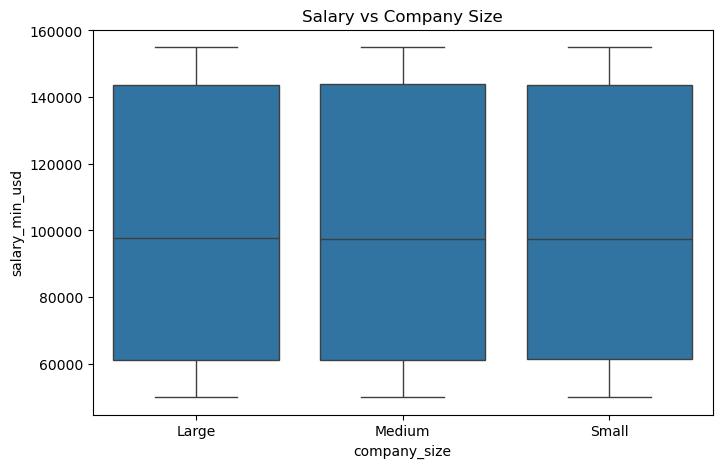

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='company_size',
    y='salary_min_usd'
)

plt.title("Salary vs Company Size")

plt.savefig(
    "../reports/figures/salary_vs_company_size.png",
    bbox_inches="tight"
)

plt.show()

# Salary vs Remote Type

Salary distributions are compared across remote work arrangements.

This helps determine whether remote, hybrid, or onsite roles offer different salary ranges.

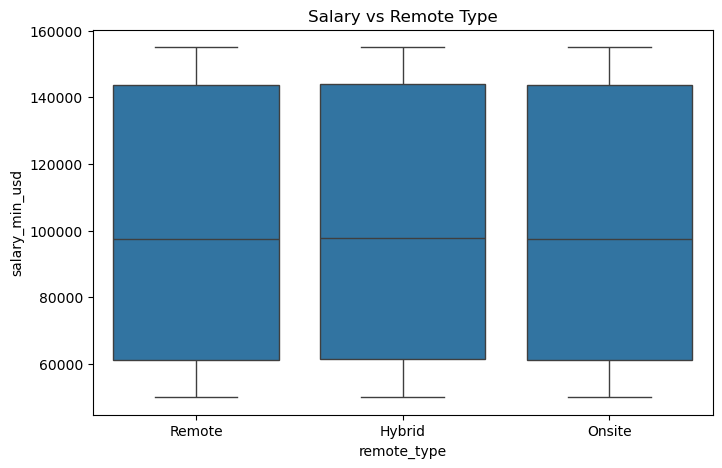

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='remote_type',
    y='salary_min_usd'
)

plt.title("Salary vs Remote Type")

plt.savefig(
    "../reports/figures/salary_vs_remote_type.png",
    bbox_inches="tight"
)

plt.show()

# Day 3 Findings

## Univariate Analysis

- Salary distributions appear balanced.
- No significant outliers were observed.
- Job titles are evenly distributed.
- Countries are evenly distributed.

## Correlation Analysis

- Strong positive correlation exists between experience and salary.
- salary_min_usd and salary_max_usd are highly correlated.
- posted_year shows almost no correlation with salary variables.

## Numeric-Categorical Analysis

- Senior roles receive the highest salaries.
- Mid-level roles receive moderate salaries.
- Entry-level roles receive the lowest salaries.

- Company size does not significantly impact salary.
- Remote type does not significantly impact salary.

## Overall Observation

The dataset appears clean, balanced, and suitable for predictive

# Day 3 Summary

## Tasks Completed

- Performed univariate analysis on salary variables.
- Created histogram, KDE plot, and boxplot.
- Analyzed job title distribution.
- Analyzed country distribution.
- Performed correlation analysis using a heatmap.
- Compared salary across experience levels.
- Compared salary across company sizes.
- Compared salary across remote work types.
- Exported all figures to reports/figures.

## Deliverables Completed

- 03_univariate_bivariate_eda.ipynb
- Correlation Heatmap
- Salary Distribution Charts
- Job Title Distribution Chart
- Country Distribution Chart
- Salary vs Experience Level Boxplot
- Salary vs Company Size Boxplot
- Salary vs Remote Type Boxplot

## Status

Day 3 Completed Successfully.

In [21]:
import os

os.listdir("../reports/figures")

['salary_vs_company_size.png',
 'country_distribution.png',
 'correlation_heatmap.png',
 'salary_vs_experience.png',
 'salary_distribution.png',
 'job_title_distribution.png',
 'salary_vs_remote_type.png']